In [1]:
# Lecture 8: Working with Files and REST API

# Tokyo, LA, London, Sydney, Paris. write method is used to string to the file. r mode reads the file, w mode opens the file, creates if it doesn't exist, and overwrites if the file exists. a mode appends, x mode if overwriting isn't allowed.

sample_data = """35.6895,139.6917
34.0522,-118.2437
51.5074,-0.1278
-33.8688,151.2093
48.8566,2.3522"""
output_file = "coordinates.txt"
try:
    with open(output_file, "w") as file:
        file.write(sample_data)
    print(f"Sample file '{output_file}' has been created successfully.")
except Exception as e:
    print(f"An error occurred while creating the file: {e}")

Sample file 'coordinates.txt' has been created successfully.


In [2]:
# practical example to read and write

# example of reading coordinates from a file and writing to another file
input_file = "coordinates.txt"
output_file = "output_coordinates.txt"

try:
    # Step 1 - read the coordinates data from our input file
    with open(input_file, "r") as infile:
        # readlines() returns a list where each element is a line from the file
        # each line still includes the newline character (\n) at the end
        coordinates = infile.readlines()
    # Step 2 - process the data and write it to a new file with better formatting
    with open(output_file, "w") as outfile:
        for line in coordinates:
            # strip() removes whitespace (\n) from both ends of the string
            # split(",") breaks the line into parts wherever it finds a comma
            lat, lon = line.strip().split(",")
            # Write the formatted data to our output file
            # The \n adds a newline character so each coordinate is on its own line
            outfile.write(f"Latitude: {lat}, Longitude: {lon}\n")
    print(f"Coordinates have been written to {output_file}")
except FileNotFoundError:
    print(f"Error: The file {input_file} was not found.")
    print("Make sure you ran the previous code cell to create the coordinates.txt file.")

Coordinates have been written to output_coordinates.txt


In [3]:
# Exception handling - if files are corrupted, missing, networks down, etc.

# try - code that might cause error
# except - runs if error occurs
# finally - optional, code block that runs regardless

# Example:

def parse_coordinates(line):
    """

    Parse a line of text into latitude and longitude coordinates.
    Args:
    line (str): A string containing coordinates in the format "lat,lon"
    Returns:
    tuple: (latitude, longitude) as floats, or None if parsing fails
    """
    try:
        # Attempt to split the line and convert to numbers
        lat, lon = line.strip().split(",")
        lat = float(lat) # ValueError if lat isn't a valid number
        lon = float(lon) # ValueError if lon isn't a valid number
        return lat, lon
    except ValueError as e:
        print(f"Data format error: {e}. Could not parse line: '{line.strip()}'\n")
        return None
    except Exception as e:
        print(f"An unexpected error occurred: {e}\n")
        return None


In [4]:
test_lines = [
    "35.6895,139.6917",
    "invalid data",
    "45.0,-119.0",
    "45.0,not_a_number",
    "only_one_value",
]
print("Testing coordinate parsing:")
for line in test_lines:
    coordinates = parse_coordinates(line)
    if coordinates:
        print(f"Successfully parsed: {coordinates}\n")
    else:
        print(f"Failed to parse: '{line}'\n")


Testing coordinate parsing:
Successfully parsed: (35.6895, 139.6917)

Data format error: not enough values to unpack (expected 2, got 1). Could not parse line: 'invalid data'

Failed to parse: 'invalid data'

Successfully parsed: (45.0, -119.0)

Data format error: could not convert string to float: 'not_a_number'. Could not parse line: '45.0,not_a_number'

Failed to parse: '45.0,not_a_number'

Data format error: not enough values to unpack (expected 2, got 1). Could not parse line: 'only_one_value'

Failed to parse: 'only_one_value'



In [5]:
# combining file handling with exception handling.

# graceful degradation - should handle as much good data as possible, skip problematic data with appropriate warnings, and continue processing

def process_geospatial_file(input_file):
    processed_count = 0
    error_count = 0
    try:
        print(f"Starting to process file: {input_file}")
        with open(input_file,"r") as infile:
            for line_number, line in enumerate(infile, 1):
                if not line.strip():
                    continue
                coordinates = parse_coordinates(line)
                if coordinates:
                    lat, lon = coordinates
                    print(
                        f"Line {line_number}: Processed coordinates ({lat:.4f},{lon:.4f})"
                    )
                    processed_count += 1
                else:
                    print(f"Line {line_number}: Skipped due to parsing error")
                    error_count += 1
    except FileNotFoundError:
        print(f"Error: The file '{input_file}' was not found.")
        print("Please check the file path and make sure the file exists.")
        return
    except PermissionError:
        print(f"Error: Permission denied when trying to read '{input_file}'.")
        print("Please check if you have read permissions for this file.")
    except Exception as e:
        print(f"An unexpected error occurred while processing the file: {e}")
        return
    finally:
        print(f"\n--- Processing Summary ---")
        print(f"Successfully processed: {processed_count} coordinates")
        print(f"Errors encountered: {error_count} lines")
        print(f"Finished processing {input_file}")

process_geospatial_file("coordinates.txt")

Starting to process file: coordinates.txt
Line 1: Processed coordinates (35.6895,139.6917)
Line 2: Processed coordinates (34.0522,-118.2437)
Line 3: Processed coordinates (51.5074,-0.1278)
Line 4: Processed coordinates (-33.8688,151.2093)
Line 5: Processed coordinates (48.8566,2.3522)

--- Processing Summary ---
Successfully processed: 5 coordinates
Errors encountered: 0 lines
Finished processing coordinates.txt


In [6]:
csv_data = """City,Latitude,Longitude
Tokyo,35.6895,139.6917
Los Angeles,34.0522,-118.2437
London,51.5074,-0.1278
Sydney,-33.8688,151.2093
Paris,48.8566,2.3522"""
output_file = "coordinates.csv"
try:
    with open(output_file, "w") as file:
        file.write(sample_data)
    print(f"Sample file '{output_file}' has been created successfully.")
except Exception as e:
    print(f"An error occurred while creating the file: {e}")

Sample file 'coordinates.csv' has been created successfully.


In [7]:
import requests
from arcgis.gis import GIS
from arcgis.features import GeoAccessor
import pandas as pd
import json

<User username:adrawal_asu>
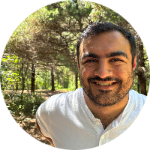

In [8]:
# set up ArcGIS Online credentials
gis = GIS("home")

# display my user info
gis.users.me

In [9]:
url = "https://phl.carto.com/api/v2/sql"
params = {
    "q": "SELECT * FROM public_cases_fc WHERE requested_datetime >= current_date - 7 AND subject = 'Illegal Dumping'",
}

response = requests.get(url, params=params)
data = response.json()

In [10]:
data

{'rows': [{'cartodb_id': 13508,
   'the_geom': '0101000020E6100000FB88D3E5B6CA52C07DB7BA72B0FC4340',
   'the_geom_webmercator': '0101000020110F00004A9B4C8A7BEB5FC15038E4143A8C5241',
   'objectid': 5475079,
   'service_request_id': 18481022,
   'subject': 'Illegal Dumping',
   'status': 'Closed',
   'status_notes': None,
   'service_name': 'Illegal Dumping',
   'service_code': 'SR-ST02',
   'agency_responsible': 'Streets Department',
   'service_notice': '5 Business Days',
   'requested_datetime': '2025-10-16T16:33:05Z',
   'updated_datetime': '2025-10-18T17:49:21Z',
   'expected_datetime': '2025-10-24T00:00:00Z',
   'closed_datetime': '2025-10-18T17:45:50Z',
   'address': '1917 RIDGE AVE',
   'zipcode': '19121',
   'media_url': None,
   'lat': 39.97413477,
   'lon': -75.16741319},
  {'cartodb_id': 14776,
   'the_geom': '0101000020E6100000AA10AE48E2CB52C0145398C183FC4340',
   'the_geom_webmercator': '0101000020110F0000A50AE61378ED5FC1CA0D3B8D088C5241',
   'objectid': 5475118,
   'servic

In [11]:
df = pd.DataFrame(data["rows"])

In [12]:
sedf = pd.DataFrame.spatial.from_xy(df, x_column="lon",y_column="lat")

In [13]:
new_item = GeoAccessor(sedf).to_featurelayer(gis = gis, title='illegal dumping')

In [14]:
new_item.id

'bceea2ee699e45a69b60d15b0c749d3e'

In [15]:
import requests
import json
from arcgis.gis import GIS
import pandas as pd

<User username:adrawal_asu>
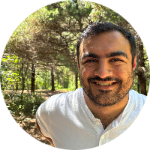

In [16]:
my_gis_org = GIS("home")
my_gis_org.users.me

In [17]:
my_item = my_gis_org.content.get('bceea2ee699e45a69b60d15b0c749d3e')

In [18]:
my_layer = my_item.layers[0]

In [19]:
df = my_layer.query(
    where='1=1',
    out_fields=['subject','status','service_code'],
    as_df=True
    )

In [20]:
list_of_dictionaries = df.to_dict(orient='records')

In [21]:
first_feature = list_of_dictionaries[0]
first_feature

{'OBJECTID': 1,
 'subject': 'Illegal Dumping',
 'status': 'Closed',
 'service_code': 'SR-ST02',
 'SHAPE': {'x': -8367598.160558388,
  'y': 4862184.326348714,
  'spatialReference': {'wkid': 102100, 'latestWkid': 3857}}}

In [22]:
payload = {"name": "New Feature", "data": first_feature}

In [23]:
payload_json = json.dumps(payload)

In [24]:
headers = {"content-type": "application/json"}

In [25]:
response = requests.post(
    url = "https://api.restful-api.dev/objects",
    data=payload_json,
    headers=headers)

response.json()

{'id': 'ff8081819782e69e019a03308e5416cc',
 'name': 'New Feature',
 'createdAt': '2025-10-20T19:55:05.172+00:00',
 'data': {'OBJECTID': 1,
  'subject': 'Illegal Dumping',
  'status': 'Closed',
  'service_code': 'SR-ST02',
  'SHAPE': {'x': -8367598.160558388,
   'y': 4862184.326348714,
   'spatialReference': {'wkid': 102100, 'latestWkid': 3857}}}}